# Import statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import seaborn as sns

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [6]:
from platform import python_version

print(python_version())



3.10.12


In [4]:
!which python3

/usr/bin/python3


In [8]:
print(np.__version__)

1.26.3


# Load dataset

In [30]:
tt_set = pd.read_pickle("pickle_files/training_data_prt.pkl")

In [31]:
tt_set.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [32]:
tt_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100_BeiJing_2013 to s99_BeiJing_2013
Columns: 251240 entries, Line to PRT
dtypes: float64(4), int64(251235), object(1)
memory usage: 2.0+ GB


In [33]:
#Final_data= Final_data.drop(['new_line'], axis=1)
tt_set.set_index('Line', inplace=True)
tt_set.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,0,0,0,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014,0,0,0,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,0,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101,0,0,1,0,0,1,1,0,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [34]:
full_pheno = tt_set.iloc[:, 251229:]
full_pheno.head()

,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,
s100,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [32]:
snps_loc= Final_data.drop(['BBD', 'LL',	'LW', 'MD',	'PLH', 'PRT'], axis=1)
snps_loc.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897,Chr20_52270629,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,2,0,2,0,0,1,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,2,0,2,0,0,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,1,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,1,0
s101,0,0,1,0,0,1,1,0,0,0,...,0,2,2,0,2,0,0,0,0,1


In [33]:
snps_all= Final_data.drop(['MD', 'PRT'], axis=1)
snps_all.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52267177,Chr20_52267897,Chr20_52270629,BBD,LL,LW,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,2,0,0,61.0,9.5000,6.26667,154.700,1,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,2,0,0,37.0,10.2200,7.19333,130.000,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,77.0,10.3667,7.76667,111.733,1,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,42.0,11.8200,7.78667,73.000,0,1,0
s101,0,0,1,0,0,1,1,0,0,0,...,2,0,0,62.0,14.2800,10.22000,95.700,0,0,1


In [ ]:
# Split training set into training and validation

In [52]:
X_train, X_test, y_train, y_test = train_test_split(snps, prt, test_size=0.2, random_state=42)

In [142]:
xgbreg = xgb.XGBRegressor(n_jobs =-1 , gamma= 1.0, learning_rate = 0.1, max_depth=7, n_estimators= 200)

In [143]:
xgbreg.fit(X_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=1.0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=-1,
             num_parallel_tree=None, random_state=None, ...)

In [144]:
y_pred_xgboost = xgbreg.predict(X_test)

In [145]:
r2_score(y_test, y_pred_xgboost)

-0.15247130393981934

In [146]:
mse = mean_squared_error(y_test, y_pred_xgboost)

In [147]:
rmse = np.sqrt(mse)
print(rmse)

26.116685046019313


# Define all functions

In [6]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}
 

In [7]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [8]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [9]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [10]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [11]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = [x for x in best_model.predict(X_holdout)]

    # Compute performance metrics
    ss = sqrt(mean_squared_error(all_preds, y_holdout))
    rr = r2_score(all_preds, y_holdout)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100

    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")

    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    plot_x, plot_y = [], []

    for counter, actual in enumerate(y_holdout):
        if counter <= 5:  # Print first 5 examples
            print(counter, actual, all_preds[counter])
        if all_preds[counter] > 1:
            plot_x.append(actual)
            plot_y.append(all_preds[counter])

    # Create a DataFrame for plotting
    thisplot = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()


    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [12]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# GWAS dataset

In [15]:
#Load file
genotype = pd.read_csv('../gwas_prt/top_1percent_snps.012', sep='\t', header=None)
genotype.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Columns: 2513 entries, 0 to 2512
dtypes: int64(2513)
memory usage: 13.3 MB


In [16]:
genotype.head()

,0,1,2,3,4,5,6,7,8,9,...,2503,2504,2505,2506,2507,2508,2509,2510,2511,2512
0,0,0,1,0,0,0,1,1,0,0,...,0,0,1,0,1,0,0,0,1,0
1,1,0,0,0,0,1,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,2,0,0,0,0,0,0,1,0,1,...,0,2,2,0,0,0,2,0,1,0
3,3,1,1,1,1,0,1,1,0,0,...,0,2,2,0,0,0,0,0,1,0
4,4,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0


In [17]:
genotype.set_index(genotype.columns[0], inplace =True)
genotype.head()

,1,2,3,4,5,6,7,8,9,10,...,2503,2504,2505,2506,2507,2508,2509,2510,2511,2512
0,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,0,0,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0
1,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,0,0,0,0,0,0,1,0,1,1,...,0,2,2,0,0,0,2,0,1,0
3,1,1,1,1,0,1,1,0,0,1,...,0,2,2,0,0,0,0,0,1,0
4,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [18]:
column_names = pd.read_csv('../gwas_prt/id_names_top1.txt', sep=' ', header=None)

In [19]:
column_names.head

<bound method NDFrame.head of                    0
0        Chr1_213719
1        Chr1_213796
2        Chr1_213831
3        Chr1_541805
4       Chr1_4323656
...              ...
2507  Chr20_47069666
2508  Chr20_47283805
2509  Chr20_47896428
2510  Chr20_50361080
2511  Chr20_51326016

[2512 rows x 1 columns]>

In [20]:
genotype.columns = column_names
genotype.info()

<class 'pandas.core.frame.DataFrame'>
Index: 696 entries, 0 to 695
Columns: 2512 entries, ('Chr1_213719',) to ('Chr20_51326016',)
dtypes: int64(2512)
memory usage: 13.3 MB


In [21]:
genotype.head()

,"(Chr1_213719,)","(Chr1_213796,)","(Chr1_213831,)","(Chr1_541805,)","(Chr1_4323656,)","(Chr1_5028106,)","(Chr1_6788897,)","(Chr1_6926781,)","(Chr1_7293438,)","(Chr1_8122682,)",...,"(Chr20_43735393,)","(Chr20_44853253,)","(Chr20_45110567,)","(Chr20_46932167,)","(Chr20_47048517,)","(Chr20_47069666,)","(Chr20_47283805,)","(Chr20_47896428,)","(Chr20_50361080,)","(Chr20_51326016,)"
0,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,0,0,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0
1,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,0,0,0,0,0,0,1,0,1,1,...,0,2,2,0,0,0,2,0,1,0
3,1,1,1,1,0,1,1,0,0,1,...,0,2,2,0,0,0,0,0,1,0
4,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [22]:
#Adding row names
rows= pd.read_csv('../gwas_prt/top_1percent_indv.txt', header=None)
rows.head()

,0
0,s63
1,s64
2,s66
3,s70
4,s71


In [23]:
genotype.index = rows
genotype.head()

,"(Chr1_213719,)","(Chr1_213796,)","(Chr1_213831,)","(Chr1_541805,)","(Chr1_4323656,)","(Chr1_5028106,)","(Chr1_6788897,)","(Chr1_6926781,)","(Chr1_7293438,)","(Chr1_8122682,)",...,"(Chr20_43735393,)","(Chr20_44853253,)","(Chr20_45110567,)","(Chr20_46932167,)","(Chr20_47048517,)","(Chr20_47069666,)","(Chr20_47283805,)","(Chr20_47896428,)","(Chr20_50361080,)","(Chr20_51326016,)"
"(s63,)",0,1,0,0,0,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0
"(s64,)",0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
"(s66,)",0,0,0,0,0,0,1,0,1,1,...,0,2,2,0,0,0,2,0,1,0
"(s70,)",1,1,1,1,0,1,1,0,0,1,...,0,2,2,0,0,0,0,0,1,0
"(s71,)",0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [24]:
genotype.to_csv('genotype_top1_percent_prt.txt', sep ='\t', index = True)

In [25]:
!sed 's/[,()\x27]//g'  genotype_top1_percent_prt.txt > genotype_top1_percent_prt_new.txt

In [26]:
#Load the genotype data
genotype_new = pd.read_csv('genotype_top1_percent_prt_new.txt', sep = '\t')
genotype_new.head()

,Unnamed: 0,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,...,Chr20_43735393,Chr20_44853253,Chr20_45110567,Chr20_46932167,Chr20_47048517,Chr20_47069666,Chr20_47283805,Chr20_47896428,Chr20_50361080,Chr20_51326016
0,s63,0,1,0,0,0,1,1,0,0,...,0,0,1,0,1,0,0,0,1,0
1,s64,0,0,0,0,1,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,s66,0,0,0,0,0,0,1,0,1,...,0,2,2,0,0,0,2,0,1,0
3,s70,1,1,1,1,0,1,1,0,0,...,0,2,2,0,0,0,0,0,1,0
4,s71,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0


In [27]:
genotype_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Columns: 2513 entries, Unnamed: 0 to Chr20_51326016
dtypes: int64(2512), object(1)
memory usage: 13.3+ MB


In [28]:
#Setting the index and naming the index column 
genotype_new = genotype_new.rename(columns={genotype_new.columns[0]: 'Line'})
genotype_new.set_index(genotype_new.columns[0])

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_43735393,Chr20_44853253,Chr20_45110567,Chr20_46932167,Chr20_47048517,Chr20_47069666,Chr20_47283805,Chr20_47896428,Chr20_50361080,Chr20_51326016
Line,,,,,,,,,,,,,,,,,,,,,
s63,0,1,0,0,0,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0
s64,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
s66,0,0,0,0,0,0,1,0,1,1,...,0,2,2,0,0,0,2,0,1,0
s70,1,1,1,1,0,1,1,0,0,1,...,0,2,2,0,0,0,0,0,1,0
s71,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s2042,0,0,1,0,0,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0
s2460,0,1,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,1
s2513,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [35]:
full_pheno.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   BBD                1094 non-null   int64  
 1   LW                 1094 non-null   float64
 2   LL                 1094 non-null   float64
 3   PLH                1094 non-null   float64
 4   BeiJing_2013       1094 non-null   int64  
 5   HeNan_2014         1094 non-null   int64  
 6   HeiLongJiang_2014  1094 non-null   int64  
 7   improved_cultivar  1094 non-null   int64  
 8   landrace           1094 non-null   int64  
 9   PRT                1094 non-null   float64
dtypes: float64(4), int64(6)
memory usage: 94.0+ KB


In [36]:
gwas_data = pd.merge(genotype_new, full_pheno, on='Line', how='outer', indicator=False)

In [37]:
gwas_data = gwas_data.reset_index().set_index('Line')

In [38]:
gwas_data= gwas_data.drop(['index'], axis=1)

In [39]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 2522 entries, Chr1_213719 to PRT
dtypes: float64(4), int64(2518)
memory usage: 21.1+ MB


In [40]:
gwas_data.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,1,0,2,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,0,0,0,0,0,1,0,2,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s101,0,0,1,2,0,0,2,0,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915
s1014,0,0,0,0,1,0,1,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,0,0,1,0,1,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667


# GWAS all traits

In [41]:
gwas_data.to_pickle("GWAS_top1percent_prt_data.pkl")
#gwas_data = pd.read_pickle("pickle_files/GWAS_top1percent_md_data.pkl")
#gwas_data.head()

In [42]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 2522 entries, Chr1_213719 to PRT
dtypes: float64(4), int64(2518)
memory usage: 21.1+ MB


In [44]:
gwas_y = gwas_data.iloc[:, 2521:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


In [45]:
gwas_all= gwas_data.drop(['PRT'], axis=1)
gwas_all.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_51326016,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,1,0,2,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,0,0,0,0,0,1,0,2,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s101,0,0,1,2,0,0,2,0,0,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1


In [46]:
gwas_all_dupe= gwas_data.drop(['PRT'], axis=1)
gwas_all_dupe.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_51326016,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,1,0,2,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,0,0,0,0,0,1,0,2,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s101,0,0,1,2,0,0,2,0,0,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1


# Run models

In [47]:
X_train, X_test, y_train, y_test = train_test_split(gwas_all, gwas_y, test_size=0.1, random_state=42)

In [48]:
X_train.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_51326016,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s174,0,0,0,0,0,0,0,1,0,0,...,0,35,7.18000,9.62667,42.7000,0,1,0,1,0
s623,0,0,0,2,1,0,1,0,0,0,...,0,57,8.40000,9.20000,63.1000,1,0,0,1,0
s237,0,0,0,0,0,0,1,0,0,0,...,0,45,7.43333,10.36670,106.4670,1,0,0,1,0
s73,0,0,0,2,0,1,1,0,0,0,...,0,66,5.03333,7.73333,99.3333,1,0,0,1,0
s195,0,0,0,0,0,0,1,0,0,1,...,0,64,8.54667,13.18000,44.9400,0,0,1,1,0


In [49]:
X_train = X_train.to_numpy()

In [50]:
y_train = y_train.to_numpy()

In [51]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4825958805302847), ('colsample_bytree', 0.4397816411246381), ('gamma', 2.0910817152625037e-05), ('learning_rate', 0.05018601860941885), ('max_delta_step', 12), ('max_depth', 50), ('min_child_weight', 4), ('n_estimators', 195), ('reg_alpha', 1.598943412668339e-08), ('reg_lambda', 1.1454274579395227e-07), ('subsample', 0.1536154650973617)])


In [13]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4825958805302847), ('colsample_bytree', 0.4397816411246381), ('gamma', 2.0910817152625037e-05), ('learning_rate', 0.05018601860941885), ('max_delta_step', 12), ('max_depth', 50), ('min_child_weight', 4), ('n_estimators', 195), ('reg_alpha', 1.598943412668339e-08), ('reg_lambda', 1.1454274579395227e-07), ('subsample', 0.1536154650973617)])

In [159]:
#gwas_all = gwas_all.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.3165800534532393
RMSE for dataset is:20.573849845471365& mean of this fold is 350.68940909090907
this is 5.866686963488543% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.9658405681268127
RMSE for dataset is:21.465062147491146& mean of this fold is 351.84669090909097
this is 6.100686094852949% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.8395622610356828
RMSE for dataset is:20.643784521163155& mean of this fold is 355.21032727272717
this is 5.811707300197117% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.133443024064888
RMSE for dataset is:23.810083506249494& mean of this fold is 351.9851454545453
this is 6.764513734095715% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.9726241452427655
RMSE fo

In [170]:
pickle.dump(best_xgbr_model, open("gwas_top1_allfeats_xgbr_prt.pickle.dat", "wb"))

<Figure size 2000x2000 with 0 Axes>

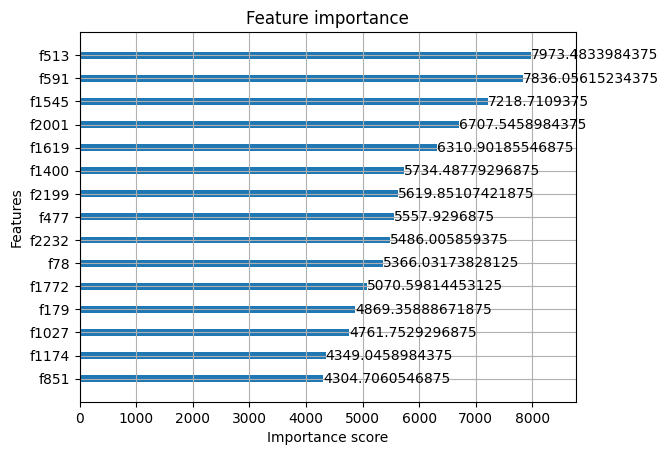

In [171]:
from xgboost import plot_importance
from matplotlib import pyplot
#best_model = pickle.load(open("Oil_kfold_10_tt_from_all.pickle.dat", "rb"))
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

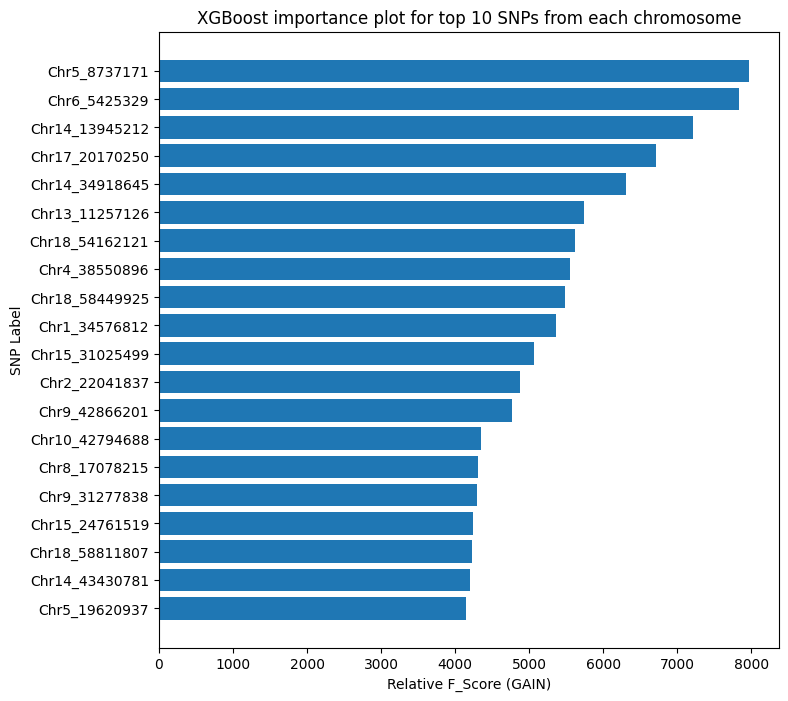

In [172]:
f_names = ['f' + str(i) for i in range(len(gwas_all_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[gwas_all_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome.png')

In [173]:
explainer = shap.Explainer(best_xgbr_model)

In [174]:
shap_values = explainer(gwas_all_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

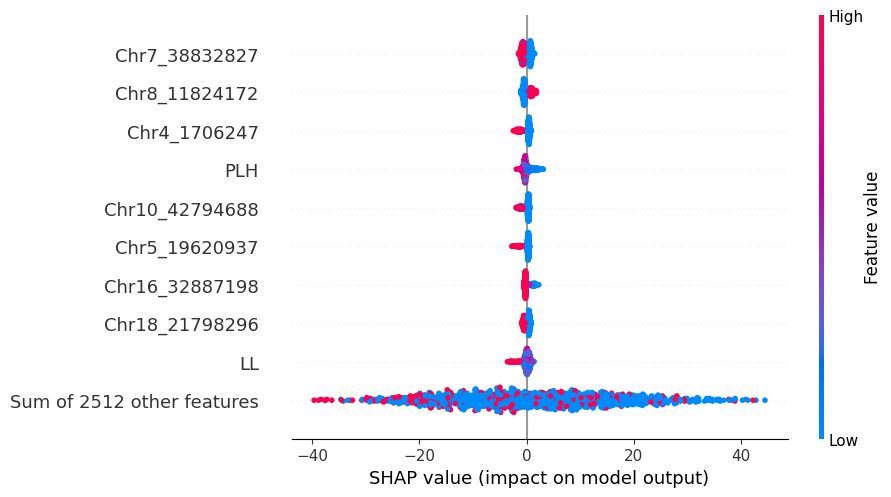

In [175]:
shap.plots.beeswarm(shap_values, show=False)

In [160]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [161]:
holdout_data = holdout_data.set_index('Line')

In [61]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [67]:
holdout_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 251239 entries, Chr1_15246 to PRT
dtypes: float64(4), int64(251235)
memory usage: 525.2+ MB


In [162]:
X_holdout = holdout_data.iloc[:, 0:251238]

In [163]:
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [164]:
y_holdout = holdout_data.iloc[:, 251238:]

In [165]:
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [166]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [167]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 2521 entries, Chr1_213719 to landrace
dtypes: float64(3), int64(2518)
memory usage: 5.3+ MB


In [168]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -1.99
RMSE of Holdout: 24.77
Mean of Holdout: 355.60
This is 6.97% of the mean pheno data
0 355.712 372.5551
1 344.136 350.54987
2 351.481 374.41028
3 353.611 377.31564
4 390.342 356.46887
5 358.958 352.5156


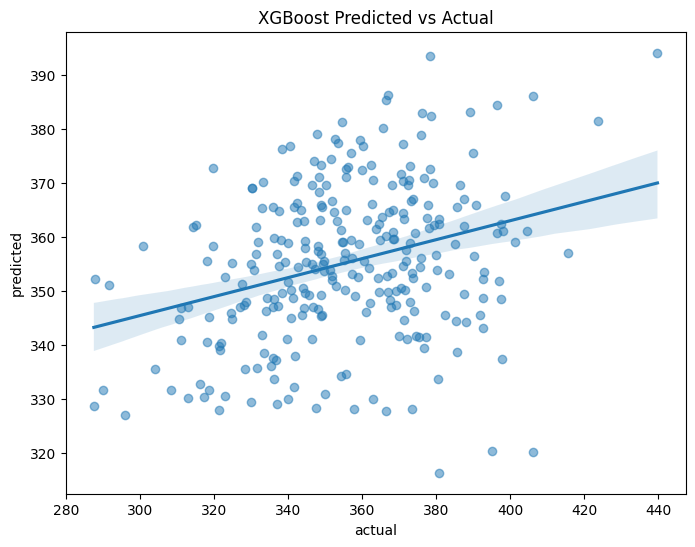

In [169]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [76]:
#### RF models

In [77]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 34), ('max_features', 'sqrt'), ('max_samples', 0.8859936093717724), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 256)])


In [78]:
best_rfr_model = eval_k_fold(best_rfreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.734958982441084
RMSE for dataset is:22.01554886441386& mean of this fold is 353.04677272727264
this is 6.235873137812476% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.379568072582995
RMSE for dataset is:22.691270977269344& mean of this fold is 354.1877181818183
this is 6.406566295904431% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.50758086591872
RMSE for dataset is:22.33558827372969& mean of this fold is 357.7913090909091
this is 6.242630188665251% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.9548981210943515
RMSE for dataset is:19.917678843546646& mean of this fold is 354.1588363636364
this is 5.623939543074384% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.774685880793567
RMSE for datase

In [79]:
pickle.dump(best_rfr_model, open("gwas_top1_allfeats_rfr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -6.95
RMSE of Holdout: 23.74
Mean of Holdout: 355.60
This is 6.68% of the mean pheno data
0 355.712 361.1141944502518
1 344.136 353.86255547332513
2 351.481 362.72473506238805
3 353.611 366.7359110146463
4 390.342 358.68291702477467
5 358.958 353.48060574184353


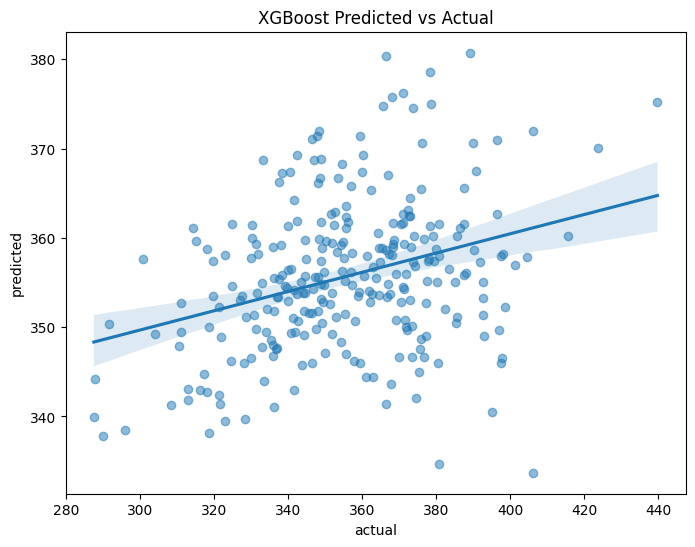

In [80]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [81]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [82]:
#gwas_all = gwas_all.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.10640256739280729
RMSE for dataset is:21.85395013267879& mean of this fold is 351.41325454545455
this is 6.218874743625252% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.23646612503303777
RMSE for dataset is:25.32374251921052& mean of this fold is 352.95701818181817
this is 7.174738343399518% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.2613890344516592
RMSE for dataset is:24.09034488920575& mean of this fold is 358.6362272727273
this is 6.717208987056984% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.012159433714840406
RMSE for dataset is:23.66432301677099& mean of this fold is 356.45003636363634
this is 6.638889213811042% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.10825077073991607
RMSE fo

In [83]:
pickle.dump(best_svr_model, open("gwas_top1_allfeats_svr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -0.82
RMSE of Holdout: 27.66
Mean of Holdout: 355.60
This is 7.78% of the mean pheno data
0 355.712 387.99598495356827
1 344.136 343.68125690491183
2 351.481 374.80039978782975
3 353.611 377.16076367606024
4 390.342 342.74965746326984
5 358.958 343.12226723507433


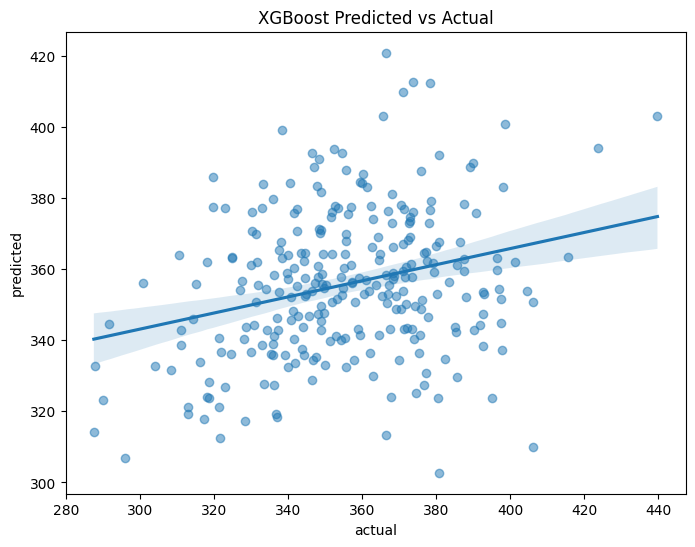

In [84]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only SNPs

In [85]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 2522 entries, Chr1_213719 to PRT
dtypes: float64(4), int64(2518)
memory usage: 21.1+ MB


In [88]:
gwas_snps = gwas_data.iloc[:, 0:2512]
gwas_snps.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_43735393,Chr20_44853253,Chr20_45110567,Chr20_46932167,Chr20_47048517,Chr20_47069666,Chr20_47283805,Chr20_47896428,Chr20_50361080,Chr20_51326016
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,0,0,0,0,0,1,0
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,0,0,0,0,0,1,0
s101,0,0,1,2,0,0,2,0,0,0,...,1,0,1,0,1,0,0,0,1,0
s1014,0,0,0,0,1,0,1,0,0,0,...,0,2,2,0,0,0,0,0,1,0
s1014,0,0,0,0,1,0,1,0,0,0,...,0,2,2,0,0,0,0,0,1,0


In [89]:
gwas_snps_dupe = gwas_data.iloc[:, 0:2512]
gwas_snps_dupe.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_43735393,Chr20_44853253,Chr20_45110567,Chr20_46932167,Chr20_47048517,Chr20_47069666,Chr20_47283805,Chr20_47896428,Chr20_50361080,Chr20_51326016
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,0,0,0,0,0,1,0
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,0,0,0,0,0,1,0
s101,0,0,1,2,0,0,2,0,0,0,...,1,0,1,0,1,0,0,0,1,0
s1014,0,0,0,0,1,0,1,0,0,0,...,0,2,2,0,0,0,0,0,1,0
s1014,0,0,0,0,1,0,1,0,0,0,...,0,2,2,0,0,0,0,0,1,0


In [90]:
gwas_y = gwas_data.iloc[:, 2521:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


# Run models

In [91]:
X_train, X_test, y_train, y_test = train_test_split(gwas_snps, gwas_y, test_size=0.1, random_state=42)

In [92]:
X_train.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_43735393,Chr20_44853253,Chr20_45110567,Chr20_46932167,Chr20_47048517,Chr20_47069666,Chr20_47283805,Chr20_47896428,Chr20_50361080,Chr20_51326016
Line,,,,,,,,,,,,,,,,,,,,,
s174,0,0,0,0,0,0,0,1,0,0,...,2,2,0,0,0,0,0,0,1,0
s623,0,0,0,2,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
s237,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
s73,0,0,0,2,0,1,1,0,0,0,...,0,0,1,0,0,0,2,0,1,0
s195,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [93]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [94]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.8110663880658012), ('colsample_bytree', 0.46427296256270645), ('gamma', 7.138210782353175e-09), ('learning_rate', 0.21881593422253529), ('max_delta_step', 20), ('max_depth', 2), ('min_child_weight', 10), ('n_estimators', 170), ('reg_alpha', 1.0), ('reg_lambda', 64.59632775823925), ('subsample', 0.37301373308727487)])


In [54]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.8110663880658012), ('colsample_bytree', 0.46427296256270645), ('gamma', 7.138210782353175e-09), ('learning_rate', 0.21881593422253529), ('max_delta_step', 20), ('max_depth', 2), ('min_child_weight', 10), ('n_estimators', 170), ('reg_alpha', 1.0), ('reg_lambda', 64.59632775823925), ('subsample', 0.37301373308727487)])

OrderedDict([('colsample_bylevel', 0.9132100359267209), ('colsample_bytree', 0.7679711803126804), ('gamma', 2.428808912219129e-07), ('learning_rate', 0.03511167856740689), ('max_delta_step', 3), ('max_depth', 8), ('min_child_weight', 4), ('n_estimators', 197), ('reg_alpha', 0.023358352781682152), ('reg_lambda', 2.1396512525873352e-07), ('scale_pos_weight', 0.001760608876847004), ('subsample', 0.15990388740095085)])


In [95]:
gwas_snps = gwas_snps.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.6610614041989238
RMSE for dataset is:19.794316219281708& mean of this fold is 348.36933636363636
this is 5.681991539754785% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.31549789632205805
RMSE for dataset is:19.695024827464323& mean of this fold is 358.70545454545453
this is 5.4905841486078115% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.4363129011542224
RMSE for dataset is:18.756605008668114& mean of this fold is 352.5008
this is 5.321010621442026% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.1739717128799234
RMSE for dataset is:16.70677172569469& mean of this fold is 355.8108181818182
this is 4.695408591303028% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.48411227885910657
RMSE for datas

In [96]:
pickle.dump(best_xgbr_model, open("gwas_top1_onlysnps_xgbr_prt.pickle.dat", "wb"))

<Figure size 2000x2000 with 0 Axes>

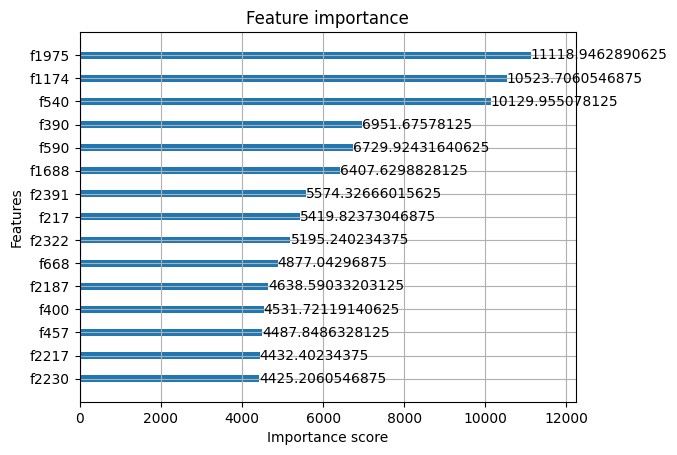

In [97]:
from xgboost import plot_importance
from matplotlib import pyplot
#best_model = pickle.load(open("Oil_kfold_10_tt_from_all.pickle.dat", "rb"))
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

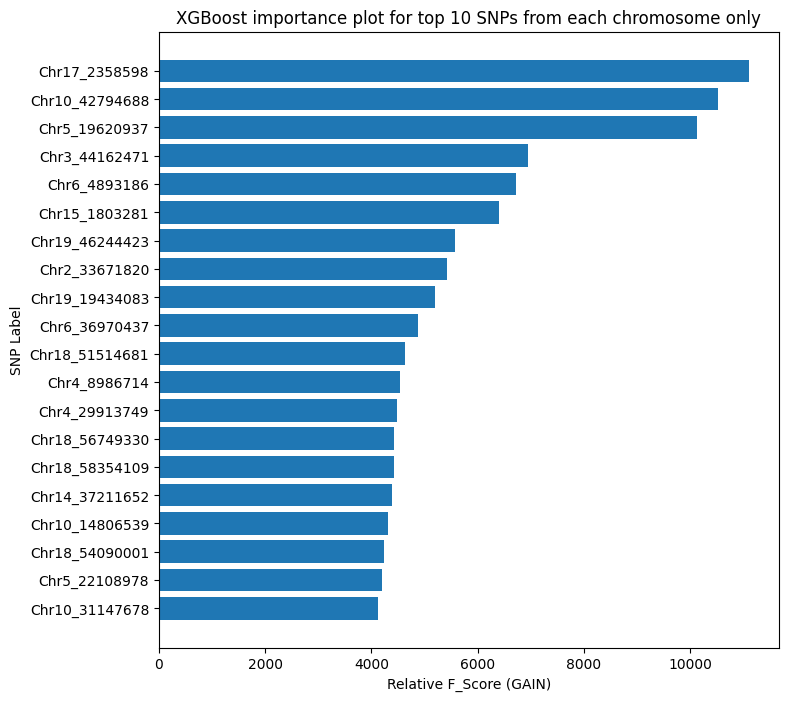

In [98]:
f_names = ['f' + str(i) for i in range(len(gwas_snps_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[gwas_snps_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome only')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome only.png')

In [99]:
explainer = shap.Explainer(best_xgbr_model)

In [100]:
shap_values = explainer(gwas_snps_dupe)

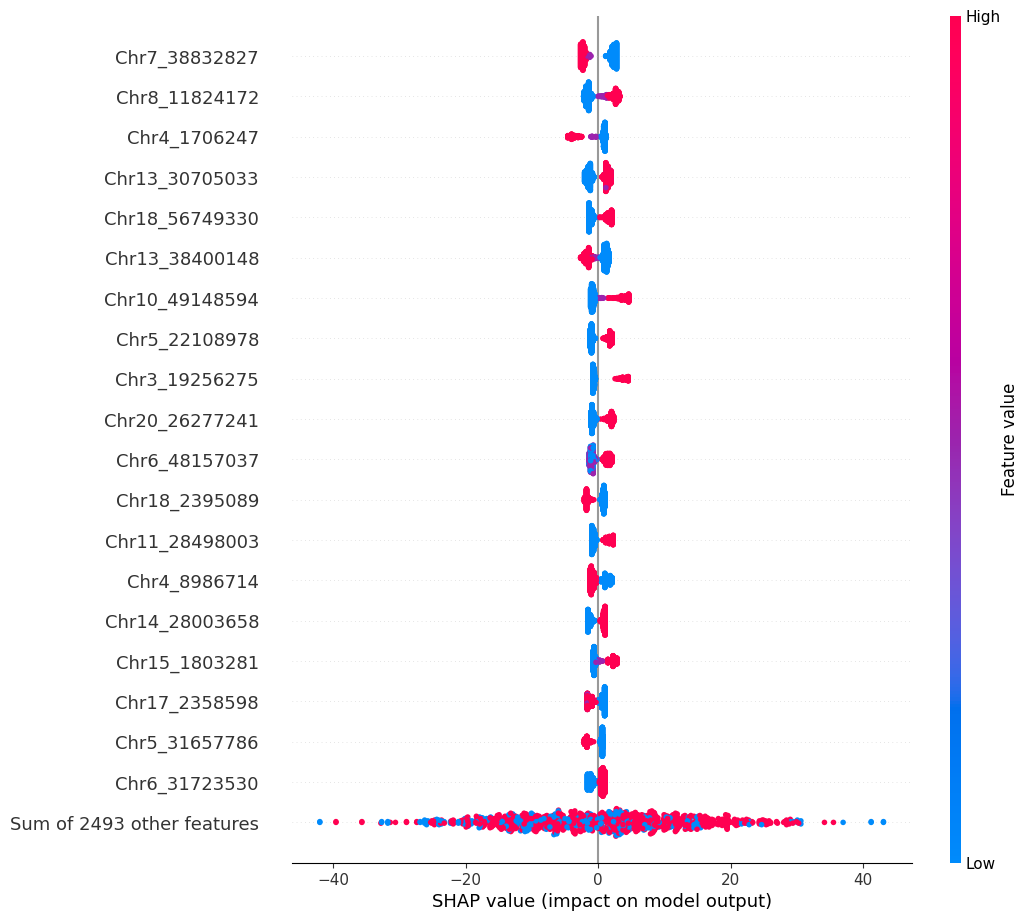

In [101]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])


In [102]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [103]:
holdout_data = holdout_data.set_index('Line')

In [104]:
holdout_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 251239 entries, Chr1_15246 to PRT
dtypes: float64(4), int64(251235)
memory usage: 525.2+ MB


In [105]:
holdout_data= holdout_data.drop(['new_line'], axis=1)

KeyError: "['new_line'] not found in axis"

In [107]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [108]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [109]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_snps, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [110]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 2512 entries, Chr1_213719 to Chr20_51326016
dtypes: int64(2512)
memory usage: 5.3+ MB


In [111]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -1.81
RMSE of Holdout: 25.49
Mean of Holdout: 355.60
This is 7.17% of the mean pheno data
0 355.712 372.14368
1 344.136 340.9908
2 351.481 365.44156
3 353.611 375.66077
4 390.342 353.85416
5 358.958 357.71323


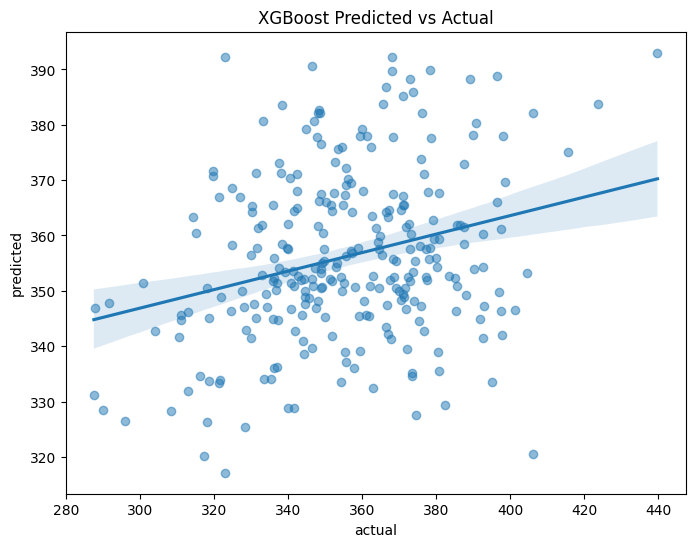

In [112]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [ ]:
#### RF models

In [113]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 34), ('max_features', 'sqrt'), ('max_samples', 0.8859936093717724), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 256)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 34), ('max_features', 'sqrt'), ('max_samples', 0.8859936093717724), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 256)])

In [117]:
gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.683517888852995
RMSE for dataset is:22.31490366803909& mean of this fold is 355.88082727272723
this is 6.270330390948033% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.454995148442904
RMSE for dataset is:20.712849707444505& mean of this fold is 350.53396363636364
this is 5.908942315481751% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.532710085967865
RMSE for dataset is:22.47145388649496& mean of this fold is 347.8636181818182
this is 6.459845960306715% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.638811150076656
RMSE for dataset is:23.556860188296998& mean of this fold is 359.03334545454555
this is 6.561190063968405% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.4779512259887557
RMSE for dat

In [118]:
pickle.dump(best_rfr_model, open("gwas_top1_onlysnps_rfr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -6.12
RMSE of Holdout: 23.75
Mean of Holdout: 355.60
This is 6.68% of the mean pheno data
0 355.712 363.154256161783
1 344.136 352.34723807205955
2 351.481 363.5319362772985
3 353.611 366.7178577464475
4 390.342 356.63268706898134
5 358.958 355.1963711072175


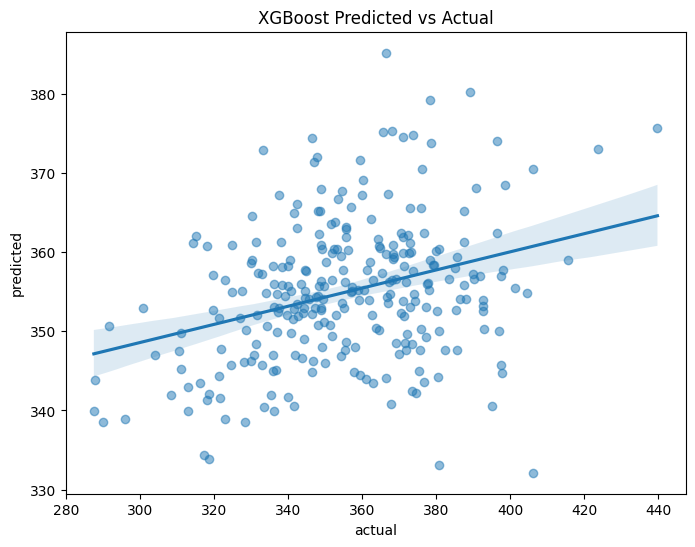

In [119]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [120]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [121]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.11333449757952985
RMSE for dataset is:23.042264827186276& mean of this fold is 353.2737
this is 6.522496530929496% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.3468722936743842
RMSE for dataset is:26.248490900703402& mean of this fold is 358.1196545454545
this is 7.329530945186311% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.20975584829265825
RMSE for dataset is:25.34926071594373& mean of this fold is 353.93114545454546
this is 7.1622011912481645% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.29090310038696954
RMSE for dataset is:23.390327082318933& mean of this fold is 351.56294545454546
this is 6.653240162178335% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.34256455234837757
RMSE for dat

In [122]:
pickle.dump(best_svr_model, open("gwas_top1_onlysnps_svr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -0.85
RMSE of Holdout: 27.63
Mean of Holdout: 355.60
This is 7.77% of the mean pheno data
0 355.712 383.41535333906705
1 344.136 348.8701213406346
2 351.481 365.1743897403884
3 353.611 377.15915151209003
4 390.342 338.8724069509182
5 358.958 360.31838036347534


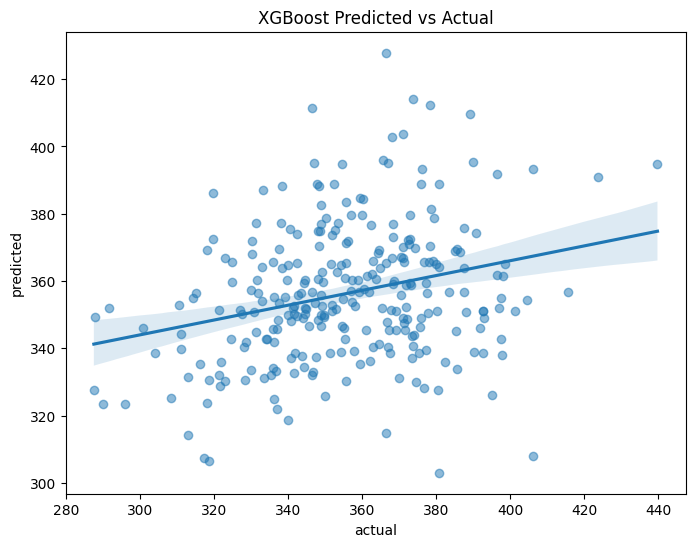

In [123]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only location

In [124]:
gwas_loc= gwas_data.drop(['PRT', 'LL',	'LW',	'PLH', 'BBD'], axis=1)
gwas_loc.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_47069666,Chr20_47283805,Chr20_47896428,Chr20_50361080,Chr20_51326016,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,1,0,1,0,0,0,1
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,1,0,0,1,0,0,1
s101,0,0,1,2,0,0,2,0,0,0,...,0,0,0,1,0,0,0,1,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,0,0,1,0,1,0,0,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,0,0,1,0,0,1,0,0,1


In [125]:
gwas_loc_dupe= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'PRT'], axis=1)
gwas_loc_dupe.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_47069666,Chr20_47283805,Chr20_47896428,Chr20_50361080,Chr20_51326016,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,1,0,1,0,0,0,1
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,1,0,0,1,0,0,1
s101,0,0,1,2,0,0,2,0,0,0,...,0,0,0,1,0,0,0,1,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,0,0,1,0,1,0,0,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,0,0,1,0,0,1,0,0,1


In [126]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 2517 entries, Chr1_213719 to landrace
dtypes: int64(2517)
memory usage: 21.0+ MB


In [128]:
gwas_y = gwas_data.iloc[:, 2521:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


In [129]:
# Run models

In [130]:
X_train, X_test, y_train, y_test = train_test_split(gwas_loc, gwas_y, test_size=0.1, random_state=42)

In [131]:
X_train.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_47069666,Chr20_47283805,Chr20_47896428,Chr20_50361080,Chr20_51326016,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s174,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,1,0
s623,0,0,0,2,1,0,1,0,0,0,...,0,0,0,1,0,1,0,0,1,0
s237,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,1,0,0,1,0
s73,0,0,0,2,0,1,1,0,0,0,...,0,2,0,1,0,1,0,0,1,0
s195,0,0,0,0,0,0,1,0,0,1,...,0,0,0,1,0,0,0,1,1,0


In [132]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [133]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4825958805302847), ('colsample_bytree', 0.4397816411246381), ('gamma', 2.0910817152625037e-05), ('learning_rate', 0.05018601860941885), ('max_delta_step', 12), ('max_depth', 50), ('min_child_weight', 4), ('n_estimators', 195), ('reg_alpha', 1.598943412668339e-08), ('reg_lambda', 1.1454274579395227e-07), ('subsample', 0.1536154650973617)])


In [70]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4825958805302847), ('colsample_bytree', 0.4397816411246381), ('gamma', 2.0910817152625037e-05), ('learning_rate', 0.05018601860941885), ('max_delta_step', 12), ('max_depth', 50), ('min_child_weight', 4), ('n_estimators', 195), ('reg_alpha', 1.598943412668339e-08), ('reg_lambda', 1.1454274579395227e-07), ('subsample', 0.1536154650973617)])

OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 2), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('scale_pos_weight', 0.060830282487222144), ('subsample', 0.13556548021189216)])


In [134]:
gwas_loc = gwas_loc.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.2055591758447655
RMSE for dataset is:22.987145765100834& mean of this fold is 353.15523636363633
this is 6.509076858606017% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.2885036734854758
RMSE for dataset is:22.24569478644696& mean of this fold is 354.54752727272717
this is 6.274390053589345% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.6043017298388333
RMSE for dataset is:21.008623921661822& mean of this fold is 356.3676454545454
this is 5.895210799752994% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.7220397747186187
RMSE for dataset is:20.563014685856594& mean of this fold is 353.69306363636366
this is 5.813802078685289% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.800300448383679
RMSE for

In [135]:
pickle.dump(best_xgbr_model, open("gwas_top1_onlyloc_xgbr_prt.pickle.dat", "wb"))

<Figure size 2000x2000 with 0 Axes>

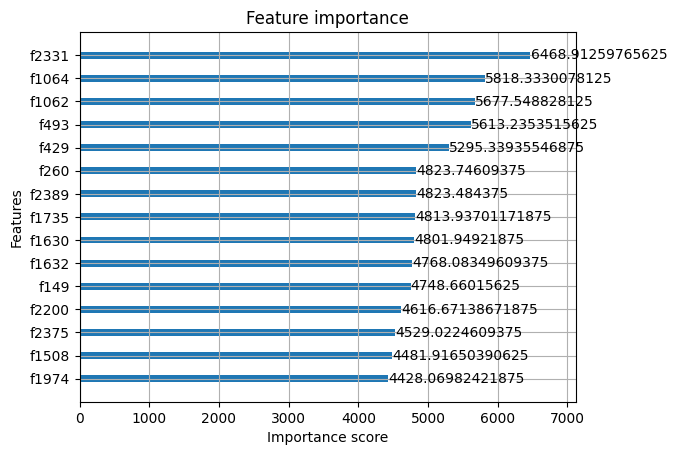

In [136]:
from xgboost import plot_importance
from matplotlib import pyplot
#best_model = pickle.load(open("Oil_kfold_10_tt_from_all.pickle.dat", "rb"))
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

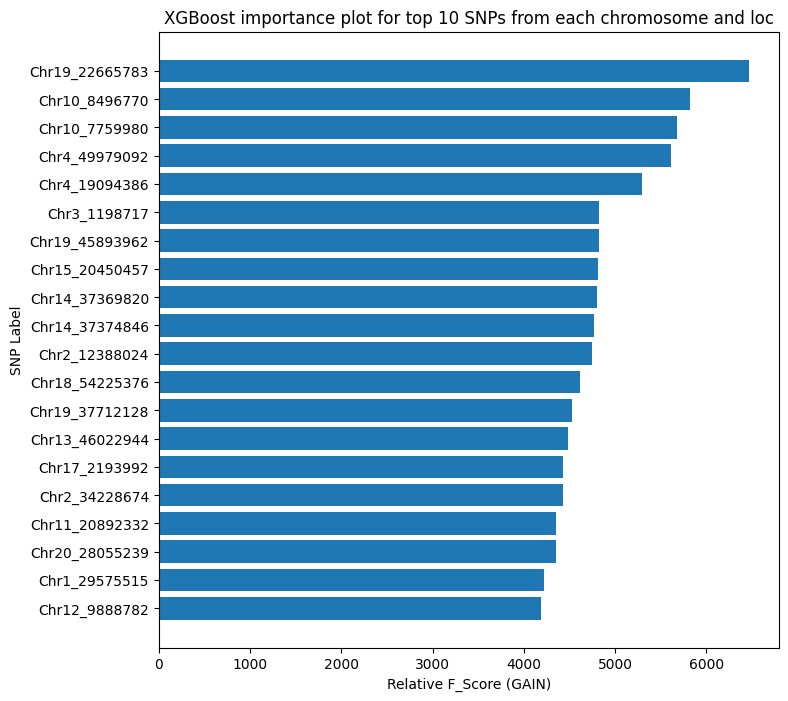

In [137]:
f_names = ['f' + str(i) for i in range(len(gwas_loc_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[gwas_loc_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome and loc')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome and loc.png')

In [138]:
explainer = shap.Explainer(best_xgbr_model)

In [139]:
shap_values = explainer(gwas_loc_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

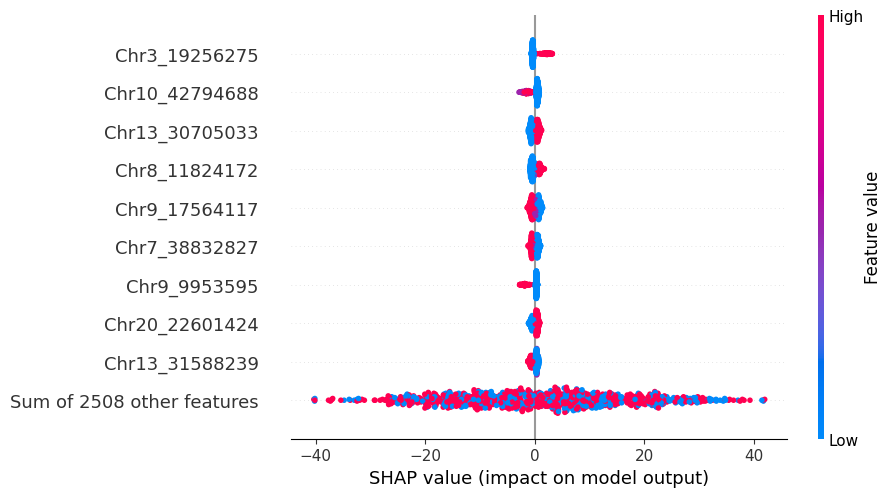

In [140]:
shap.plots.beeswarm(shap_values, show=False)

In [141]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [142]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [143]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [144]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [145]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [146]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 2517 entries, Chr1_213719 to landrace
dtypes: int64(2517)
memory usage: 5.3+ MB


In [147]:
X_holdout.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_47069666,Chr20_47283805,Chr20_47896428,Chr20_50361080,Chr20_51326016,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,2,0,0,2,0,0,0,...,0,0,0,1,0,1,0,0,0,1
s102,0,0,1,2,0,0,1,0,0,0,...,0,0,0,1,0,0,0,1,0,1
s110,0,0,0,0,0,0,1,0,0,0,...,0,0,1,1,0,1,0,0,0,1
s112,0,0,0,1,0,0,1,0,0,0,...,0,0,0,1,0,1,0,0,0,1
s113,0,0,0,1,0,0,1,0,0,0,...,1,2,2,1,0,1,0,0,0,1


In [148]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -2.03
RMSE of Holdout: 24.92
Mean of Holdout: 355.60
This is 7.01% of the mean pheno data
0 355.712 366.34503
1 344.136 351.6125
2 351.481 371.69827
3 353.611 362.99063
4 390.342 353.90274
5 358.958 358.07156


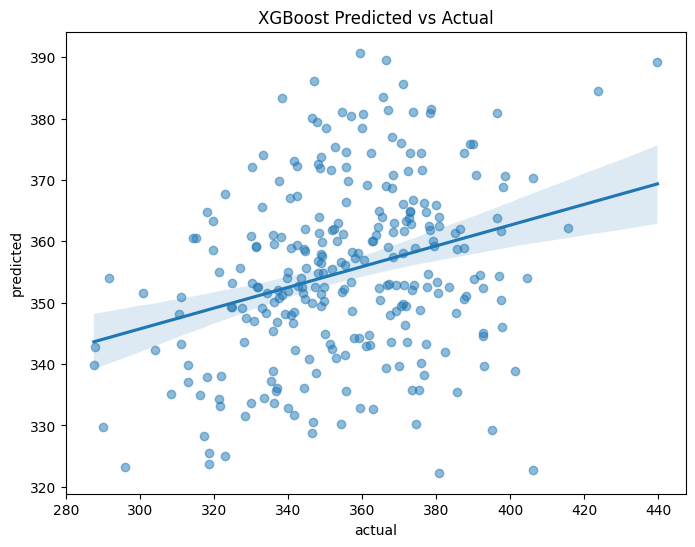

In [149]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [150]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 23), ('max_features', 'sqrt'), ('max_samples', 0.9951487285762164), ('min_samples_leaf', 1), ('min_samples_split', 16), ('n_estimators', 217)])


In [2]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 23), ('max_features', 'sqrt'), ('max_samples', 0.9951487285762164), ('min_samples_leaf', 1), ('min_samples_split', 16), ('n_estimators', 217)])

In [152]:
gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.8909346984243194
RMSE for dataset is:18.931320354111676& mean of this fold is 353.90361818181805
this is 5.3492870322636% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.732656290902477
RMSE for dataset is:24.878445018689263& mean of this fold is 354.50762727272723
this is 7.017746052484777% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.406010451391242
RMSE for dataset is:20.405257435153374& mean of this fold is 352.7941636363637
this is 5.7838988108050815% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.968484772080717
RMSE for dataset is:21.46011166105692& mean of this fold is 354.13120909090907
this is 6.059932338679558% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.6911087264902234
RMSE for da

In [153]:
pickle.dump(best_rfr_model, open("gwas_top1_onlyloc_rfr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -4.79
RMSE of Holdout: 23.63
Mean of Holdout: 355.60
This is 6.64% of the mean pheno data
0 355.712 364.0949706195025
1 344.136 352.3880921177602
2 351.481 359.98889438089435
3 353.611 368.28444001563065
4 390.342 357.1095730973992
5 358.958 353.5018433126076


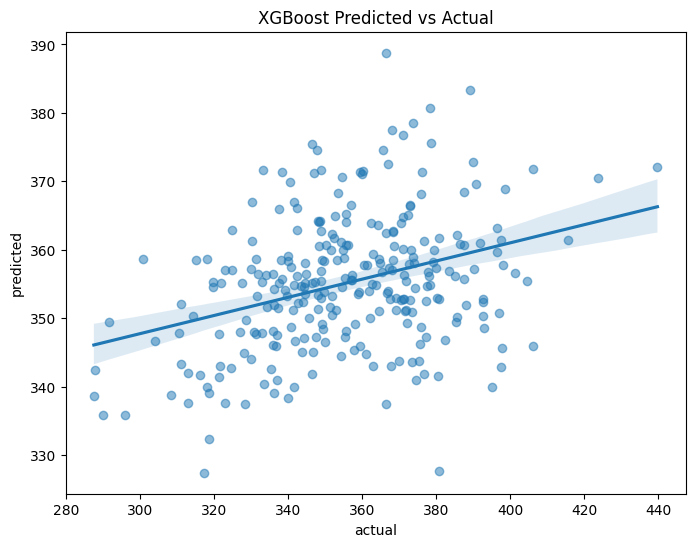

In [154]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [155]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [156]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.23454276031816446
RMSE for dataset is:26.696666159840056& mean of this fold is 352.33650909090915
this is 7.577036574700193% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.48189853975668906
RMSE for dataset is:23.0216518036662& mean of this fold is 356.99339090909086
this is 6.448761346825245% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.1621591491438763
RMSE for dataset is:22.676650532042416& mean of this fold is 354.2816363636363
this is 6.400741163103072% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.14565896512741383
RMSE for dataset is:23.530387251235354& mean of this fold is 354.3948818181819
this is 6.639595676584105% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.20454704262781642
RMSE 

In [157]:
pickle.dump(best_svr_model, open("gwas_top1_onlyloc_svr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -0.78
RMSE of Holdout: 27.11
Mean of Holdout: 355.60
This is 7.62% of the mean pheno data
0 355.712 393.27263691164876
1 344.136 343.18955949348634
2 351.481 377.66348952854986
3 353.611 376.4545990212361
4 390.342 340.17220830192304
5 358.958 353.62387367032


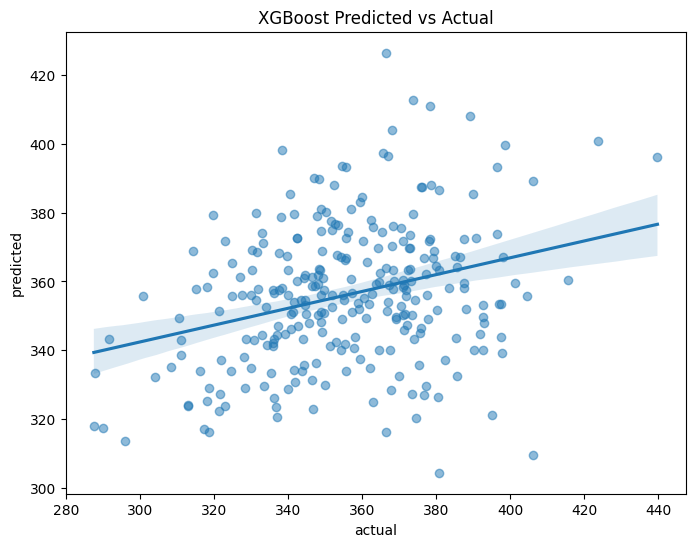

In [158]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)